# TP1 — Bin Packing : Tests et résultats

Equipe n°4 • Année universitaire : 2025-2026

---

Ce notebook présente une étude expérimentale du problème de Bin Packing : ranger un ensemble de $n$ objets, chacun de poids $w_i$, dans un nombre minimal de bins de capacité $C$.

Trois méthodes exactes sont implémentées dans le module `bin_packing.solver` :
- **Branch and Bound** avec borne inférieure L1 et borne supérieure donnée par l'heuristique First Fit Decreasing (FFD).
- **Backtracking** avec coupures par symétrie et initialisation FFD.
- **Programmation dynamique** par masque de bits (bitmask DP).

---

## 1. Conception de l'algorithme (Branch and Bound)

### 1.1 Borne supérieure (Upper Bound) — Heuristique FFD

Avant la recherche exacte, on initialise la borne supérieure via l'heuristique **First-Fit Decreasing (FFD)** :

1. Trier les objets par taille **décroissante**.
2. Pour chaque objet, le placer dans la **première boîte** où il tient.
3. Si aucune boîte ne convient, ouvrir une nouvelle boîte.

FFD garantit une solution dont le nombre de bacs est au plus $\frac{11}{9} \, OPT + \frac{6}{9}$, où $OPT$ désigne le nombre minimal de bacs pour une instance donnée.

### 1.2 Borne inférieure (Lower Bound) — L1

La borne L1 est :

$$LB = \left\lceil \frac{\sum_{i \in R} s_i}{C} \right\rceil$$

où $R$ est l'ensemble des objets restants à placer. C'est la borne la plus simple : il faut au moins autant de bins que le remplissage parfait l'exigerait.

### 1.3 Stratégie d'exploration de l'arbre

Nous faisons une exploration de type **Depth-First Search (DFS)** via une pile explicite. À chaque nœud, on représente l'état par :
- `item_index` : l'indice du prochain objet à placer,
- `current_bin_loads` : la charge courante de chaque bin ouvert,
- `assignments` : l'affectation de chaque objet traité.

### 1.4 Fonction d'évaluation et élagage (Pruning)

Pour chaque nœud, on calcule :

$$f(n) = \text{bins déjà ouverts} + LB(\text{objets restants})$$

**Règle de coupe :** si $f(n) \geq \text{meilleure solution connue}$, on **élague** la branche.

### 1.5 Brisure de symétrie

Les bins avec la même charge (`load`) sont **interchangeables**. On ne tente jamais deux placements dans deux bins de même charge, ce qui réduit drastiquement l'espace de recherche.

---

## 2. Méthodes supplémentaires

Deux autres méthodes exactes ont été implémentées dans ce TP :

### 2.1 Backtracking
Exploration exhaustive de l'arbre de recherche avec **brisure de symétrie** : on ne tente jamais deux placements dans des bins de même charge, ce qui évite les chemins redondants. La borne supérieure FFD sert de seuil d'élagage.

### 2.2 Programmation Dynamique (Bitmask DP) 
Approche exacte par DP sur les sous-ensembles, limitée à $n \leq 20$ objets :

$$dp[\text{mask}] = \min_{\text{submask} \subseteq \text{mask},\ \text{sum(submask)} \leq C} \left( dp[\text{mask} \setminus \text{submask}] + 1 \right)$$

Complexité : $O(3^n)$ en temps, $O(2^n)$ en espace. Au-delà de 20 objets, le coût mémoire devient prohibitif.

---

## 3. Mise en place

In [13]:
# ── Imports & path setup ─────────────────────────────────────────────────────
%matplotlib inline
import sys, time, random
from math import ceil
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from matplotlib.colors import Normalize

# Add the project root to sys.path so we can import bin_packing
PROJECT_ROOT = Path('.').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from solver import BinPackingSolver, BinPackingSolution

print("Imports OK — projet root:", PROJECT_ROOT)

Imports OK — projet root: D:\2CS\S2\OPTIM\TP1\bin_packing


---

## 4. Tests sur des instances simples

Nous commençons par valider les trois méthodes sur des instances simples pour s'assurer de la correction.

In [14]:
# ── Helper : résoudre et afficher les résultats sur une instance ─────────────
def run_instance(sizes, capacity, label="Instance", methods=None):
    if methods is None:
        methods = ["backtracking", "branch and bound", "dynamic programming"]
    lb = ceil(sum(sizes) / capacity)
    print(f"\n{'─'*60}")
    print(f"  {label}")
    print(f"  Objets (n={len(sizes)}) : {sorted(sizes, reverse=True)}")
    print(f"  Capacité C = {capacity}  |  Somme = {sum(sizes)}  |  LB = {lb}")
    print(f"{'─'*60}")
    print(f"  {'Méthode':<25} {'Bins':>5} {'Gap':>5} {'Temps (s)':>12} {'Optimal?':>10}")
    print(f"  {'─'*25} {'─'*5} {'─'*5} {'─'*12} {'─'*10}")
    results = {}
    for method in methods:
        try:
            solver = BinPackingSolver(sizes, capacity)
            t0 = time.perf_counter()
            solver.solve(method)
            elapsed = time.perf_counter() - t0
            sol = solver.get_solution()
            gap = sol.total_bins_used - lb
            optimal = "OUI" if gap == 0 else "NON"
            print(f"  {method:<25} {sol.total_bins_used:>5} {gap:>5} {elapsed:>12.6f} {optimal:>10}")
            results[method] = sol
        except Exception as e:
            print(f"  {method:<25} {'N/A':>5} {'N/A':>5} {'N/A':>12}  {e}")
    return 0

# ── Instance 1 : triviale ─────────────────────────────────────────────────────
run_instance(
    sizes=[4, 3, 3, 2, 2, 1],
    capacity=5,
    label="Instance 1 — triviale (n=6, C=5)"
)

# ── Instance 2 : classique ────────────────────────────────────────────────────
run_instance(
    sizes=[10, 9, 6, 5, 5, 4, 4, 3, 3, 2],
    capacity=10,
    label="Instance 2 — classique (n=10, C=10)"
)

# ── Instance 3 : objets uniformes ─────────────────────────────────────────────
run_instance(
    sizes=[6, 6, 6, 5, 5, 5, 4, 4, 4],
    capacity=11,
    label="Instance 3 — objets uniformes (n=9, C=11)"
)


────────────────────────────────────────────────────────────
  Instance 1 — triviale (n=6, C=5)
  Objets (n=6) : [4, 3, 3, 2, 2, 1]
  Capacité C = 5  |  Somme = 15  |  LB = 3
────────────────────────────────────────────────────────────
  Méthode                    Bins   Gap    Temps (s)   Optimal?
  ───────────────────────── ───── ───── ──────────── ──────────
  backtracking                  3     0     0.000068        OUI
  branch and bound              3     0     0.000047        OUI
  dynamic programming           3     0     0.000787        OUI

────────────────────────────────────────────────────────────
  Instance 2 — classique (n=10, C=10)
  Objets (n=10) : [10, 9, 6, 5, 5, 4, 4, 3, 3, 2]
  Capacité C = 10  |  Somme = 51  |  LB = 6
────────────────────────────────────────────────────────────
  Méthode                    Bins   Gap    Temps (s)   Optimal?
  ───────────────────────── ───── ───── ──────────── ──────────
  backtracking                  6     0     0.000217        

0

---

## 5. Visualisation des solutions

Pour une instance donnée, on visualise graphiquement l'affectation des objets dans les bins.

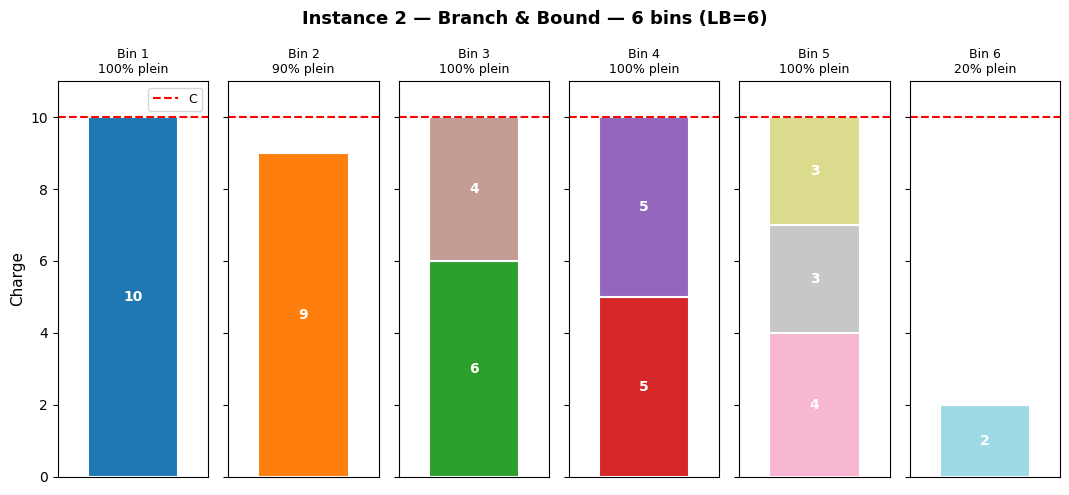

In [ ]:
def plot_solution(sizes, capacity, solution: BinPackingSolution, title="Solution Bin Packing"):
    """Visualise l'affectation des objets dans les bins."""
    n_bins = solution.total_bins_used
    cmap = plt.get_cmap("tab20", len(sizes))

    fig, axes = plt.subplots(1, n_bins, figsize=(max(8, n_bins * 1.8), 5),
                             sharey=True)
    if n_bins == 1:
        axes = [axes]

    sorted_sizes = sorted(sizes, reverse=True)  # solver sorts items

    for bin_idx, ax in enumerate(axes):
        items = solution.bin_assignments.get(bin_idx, [])
        bottom = 0
        for item_idx in items:
            item_size = sorted_sizes[item_idx]
            ax.bar(0, item_size, bottom=bottom, width=0.6,
                   color=cmap(item_idx), edgecolor='white', linewidth=1.5)
            ax.text(0, bottom + item_size / 2, str(item_size),
                    ha='center', va='center', fontsize=10, fontweight='bold', color='white')
            bottom += item_size
        ax.axhline(capacity, color='red', linestyle='--', linewidth=1.5, label='C' if bin_idx == 0 else '')
        fill = bottom / capacity * 100
        ax.set_title(f"Bin {bin_idx+1}\n{fill:.0f}% plein", fontsize=9)
        ax.set_ylim(0, capacity * 1.1)
        ax.set_xlim(-0.5, 0.5)
        ax.set_xticks([])
        if bin_idx == 0:
            ax.set_ylabel("Charge", fontsize=11)

    fig.suptitle(title, fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=9)
    plt.tight_layout()
    plt.show()

# Visualisation de l'instance 2 avec Branch & Bound
sizes_demo = [10, 9, 6, 5, 5, 4, 4, 3, 3, 2]
capacity_demo = 10
solver = BinPackingSolver(sizes_demo, capacity_demo)
solver.solve("branch and bound")
sol = solver.get_solution()
plot_solution(sizes_demo, capacity_demo, sol,
              title=f"Instance 2 — Branch & Bound — {sol.total_bins_used} bins (LB={ceil(sum(sizes_demo)/capacity_demo)})")

---

## 6. Comparaison des méthodes — Temps de calcul vs Taille

On compare les trois méthodes sur des instances générées aléatoirement de taille croissante.

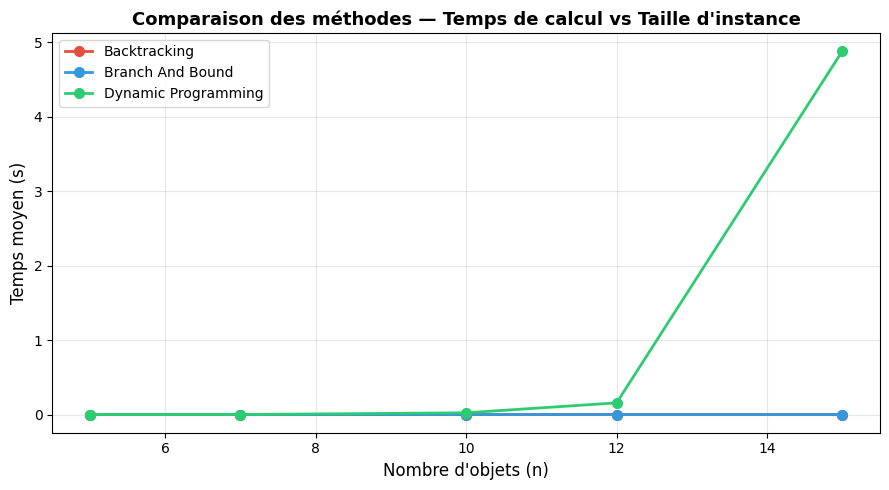

In [16]:
random.seed(42)
CAPACITY = 100
sizes_range = (20, 80)
N_VALUES = [5, 7, 10, 12, 15]
N_REPEAT = 3  # instances par taille

methods = ["backtracking", "branch and bound", "dynamic programming"]
colors  = {"backtracking": "#e74c3c",
           "branch and bound": "#3498db",
           "dynamic programming": "#2ecc71"}

results = {m: {n: [] for n in N_VALUES} for m in methods}

for n in N_VALUES:
    for _ in range(N_REPEAT):
        sizes = [random.randint(*sizes_range) for _ in range(n)]
        for method in methods:
            if method == "dynamic programming" and n > 20:
                continue
            try:
                solver = BinPackingSolver(sizes, CAPACITY)
                t0 = time.perf_counter()
                solver.solve(method)
                elapsed = time.perf_counter() - t0
                results[method][n].append(elapsed)
            except Exception:
                pass

fig, ax = plt.subplots(figsize=(9, 5))

for method in methods:
    avg_times = []
    valid_ns  = []
    for n in N_VALUES:
        ts = results[method][n]
        if ts:
            avg_times.append(sum(ts) / len(ts))
            valid_ns.append(n)
    if avg_times:
        ax.plot(valid_ns, avg_times, marker='o', label=method.title(),
                color=colors[method], linewidth=2, markersize=7)

ax.set_xlabel("Nombre d'objets (n)", fontsize=12)
ax.set_ylabel("Temps moyen (s)", fontsize=12)
ax.set_title("Comparaison des méthodes — Temps de calcul vs Taille d'instance",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Benchmark sur les jeux de données standard

Nous utilisons le module `benchmark.py` pour évaluer Branch & Bound sur les instances **Falkenauer T** et **Scholl 1**.

> Cette section requiert la présence des fichiers de benchmark dans `benchmarks/`.

In [17]:
from benchmark import (
    Benchmark, DATASET_REGISTRY, BenchmarkResult
)
import pandas as pd

def results_to_df(results: list[BenchmarkResult]) -> pd.DataFrame:
    return pd.DataFrame([
        {
            "Instance":  r.instance_name,
            "Items":     r.num_items,
            "Capacity":  r.bin_capacity,
            "LB":        r.lower_bound,
            "Bins":      r.bins_used,
            "Gap":       r.bins_used - r.lower_bound,
            "Time (s)":  round(r.elapsed_time, 4),
            "Optimal":   r.bins_used == r.lower_bound,
            "T.O.":      r.timed_out,
        }
        for r in results
    ])

In [6]:
# ── Falkenauer T — instances ≤ 60 items avec Branch & Bound ──────────────────
try:
    bench_ft = Benchmark(DATASET_REGISTRY["falkenauer-t"], time_limit=30)
    bench_ft.run(method="branch and bound", max_items=60, generate_graphs=False)
    df_ft = results_to_df(bench_ft.get_results())
    print(df_ft.to_string(index=False))
except FileNotFoundError as e:
    print(f"Dataset introuvable : {e}")
    df_ft = None


Starting Benchmark: Falkenauer T
──────────────────────────────────────────────────────────────────────────────────────────────
Instance          │ Items │ Capacity │ LB │ Bins │ Gap │ Time (s)   │ Method           │ State
──────────────────────────────────────────────────────────────────────────────────────────────
Falkenauer_t60_00 │ 60    │ 1000     │ 20 │ 23   │ 3   │ 2.3221     │ branch and bound │ Done 
Falkenauer_t60_01 │ 60    │ 1000     │ 20 │ 23   │ 3   │ 1.3118     │ branch and bound │ Done 
Falkenauer_t60_02 │ 60    │ 1000     │ 20 │ 23   │ 3   │ 6.9742     │ branch and bound │ Done 
Falkenauer_t60_03 │ 60    │ 1000     │ 20 │ 23   │ 3   │ 7.7093     │ branch and bound │ Done 
Falkenauer_t60_04 │ 60    │ 1000     │ 20 │ 20   │ 0   │ 30.0000    │ branch and bound │ T.O. 
Falkenauer_t60_05 │ 60    │ 1000     │ 20 │ 23   │ 3   │ 3.2512     │ branch and bound │ Done 
Falkenauer_t60_06 │ 60    │ 1000     │ 20 │ 23   │ 3   │ 1.5314     │ branch and bound │ Done 
Falkenauer_t60_0

In [7]:
# ── Scholl 1 — Branch & Bound, limite 20 s par instance ──────────────────────
try:
    bench_s1 = Benchmark(DATASET_REGISTRY["scholl-1"], time_limit=20)
    bench_s1.run(method="branch and bound", max_items=50, generate_graphs=False)
    df_s1 = results_to_df(bench_s1.get_results())
    print(df_s1.to_string(index=False))
except FileNotFoundError as e:
    print(f"Dataset introuvable : {e}")
    df_s1 = None


Starting Benchmark: Scholl 1
─────────────────────────────────────────────────────────────────────────────────────
Instance │ Items │ Capacity │ LB │ Bins │ Gap │ Time (s)   │ Method           │ State
─────────────────────────────────────────────────────────────────────────────────────
N1C1W1_A │ 50    │ 100      │ 25 │ 25   │ 0   │ 0.0001     │ branch and bound │ Done 
N1C1W1_B │ 50    │ 100      │ 28 │ 31   │ 3   │ 0.0002     │ branch and bound │ Done 
N1C1W1_C │ 50    │ 100      │ 20 │ 21   │ 1   │ 0.0001     │ branch and bound │ Done 
N1C1W1_D │ 50    │ 100      │ 26 │ 28   │ 2   │ 0.0002     │ branch and bound │ Done 
N1C1W1_E │ 50    │ 100      │ 25 │ 26   │ 1   │ 0.0001     │ branch and bound │ Done 
N1C1W1_F │ 50    │ 100      │ 26 │ 27   │ 1   │ 0.0001     │ branch and bound │ Done 
N1C1W1_G │ 50    │ 100      │ 25 │ 25   │ 0   │ 0.0001     │ branch and bound │ Done 
N1C1W1_H │ 50    │ 100      │ 28 │ 31   │ 3   │ 0.0002     │ branch and bound │ Done 
N1C1W1_I │ 50    │ 100  

---

## 8. Graphiques d'analyse

Les graphiques suivants reproduisent les 4 figures à partir des résultats collectés ci-dessus.

In [18]:
import dataclasses

def make_demo_results(seed=0):
    """Génère des résultats synthétiques réalistes pour la démonstration."""
    rng = random.Random(seed)
    demo = []
    for i in range(20):
        n    = rng.choice([20, 40, 60, 80])
        cap  = 100
        lb   = rng.randint(max(5, n//4), n//3)
        gap  = rng.choices([0, 0, 0, 1, 2], k=1)[0]
        bins = lb + gap
        t    = rng.uniform(0.001, 2.5) * (n / 20) ** 2.2
        demo.append(BenchmarkResult(
            instance_name=f"inst_{i+1:02d}",
            dataset_key="demo",
            num_items=n,
            bin_capacity=cap,
            bins_used=bins,
            lower_bound=lb,
            total_weight=lb * cap - rng.randint(0, cap // 5),
            elapsed_time=t,
            method="branch and bound",
            timed_out=False,
        ))
    return demo

# Utilise les vrais résultats s'ils existent, sinon les données démo
if 'bench_ft' in dir() and bench_ft.get_results():
    display_results = bench_ft.get_results()
    dataset_label   = "Falkenauer T"
elif 'bench_s1' in dir() and bench_s1.get_results():
    display_results = bench_s1.get_results()
    dataset_label   = "Scholl 1"
else:
    display_results = make_demo_results()
    dataset_label   = "Données de démonstration"

completed = [r for r in display_results if not r.timed_out]
print(f"📊 Affichage des graphiques pour : {dataset_label} ({len(completed)} instances)")

📊 Affichage des graphiques pour : Données de démonstration (20 instances)


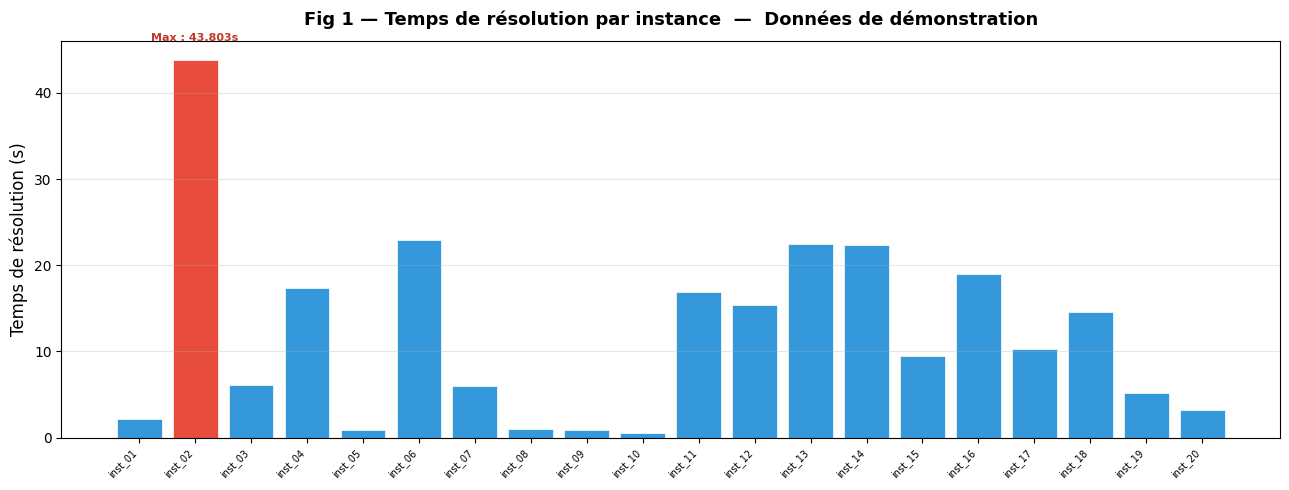

In [19]:
# ── Fig 1 : Temps de résolution par instance ──────────────────────────────────
fig, ax = plt.subplots(figsize=(max(10, len(completed) * 0.65), 5))

times  = [r.elapsed_time for r in completed]
max_t  = max(times)
colors = ["#e74c3c" if t == max_t else "#3498db" for t in times]

ax.bar(range(len(completed)), times, color=colors, edgecolor="white", linewidth=0.5)
ax.set_xticks(range(len(completed)))
ax.set_xticklabels([r.instance_name for r in completed], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Temps de résolution (s)", fontsize=12)
ax.set_title(f"Fig 1 — Temps de résolution par instance  —  {dataset_label}",
             fontsize=13, fontweight="bold", pad=12)
ax.grid(axis='y', alpha=0.3)

# Annotation du max
max_idx = times.index(max_t)
ax.annotate(f"Max : {max_t:.3f}s", xy=(max_idx, max_t),
            xytext=(max_idx, max_t * 1.05),
            ha='center', fontsize=8, color='#c0392b', fontweight='bold')

fig.tight_layout()
#plt.show()

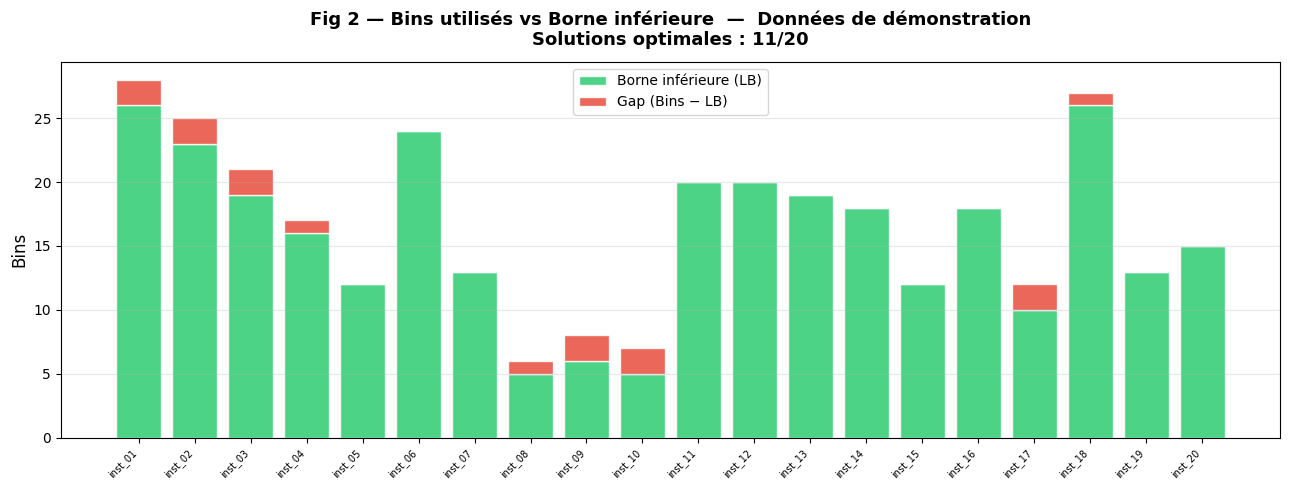

In [20]:
# ── Fig 2 : Bins utilisés vs Borne inférieure ─────────────────────────────────
fig, ax = plt.subplots(figsize=(max(10, len(completed) * 0.65), 5))

x        = range(len(completed))
lb_vals  = [r.lower_bound for r in completed]
gap_vals = [r.bins_used - r.lower_bound for r in completed]
n_opt    = sum(1 for g in gap_vals if g == 0)

ax.bar(x, lb_vals,  label="Borne inférieure (LB)", color="#2ecc71", alpha=0.85, edgecolor="white")
ax.bar(x, gap_vals, bottom=lb_vals, label="Gap (Bins − LB)", color="#e74c3c", alpha=0.85, edgecolor="white")

ax.set_xticks(list(x))
ax.set_xticklabels([r.instance_name for r in completed], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Bins", fontsize=12)
ax.set_title(f"Fig 2 — Bins utilisés vs Borne inférieure  —  {dataset_label}\n"
             f"Solutions optimales : {n_opt}/{len(completed)}",
             fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

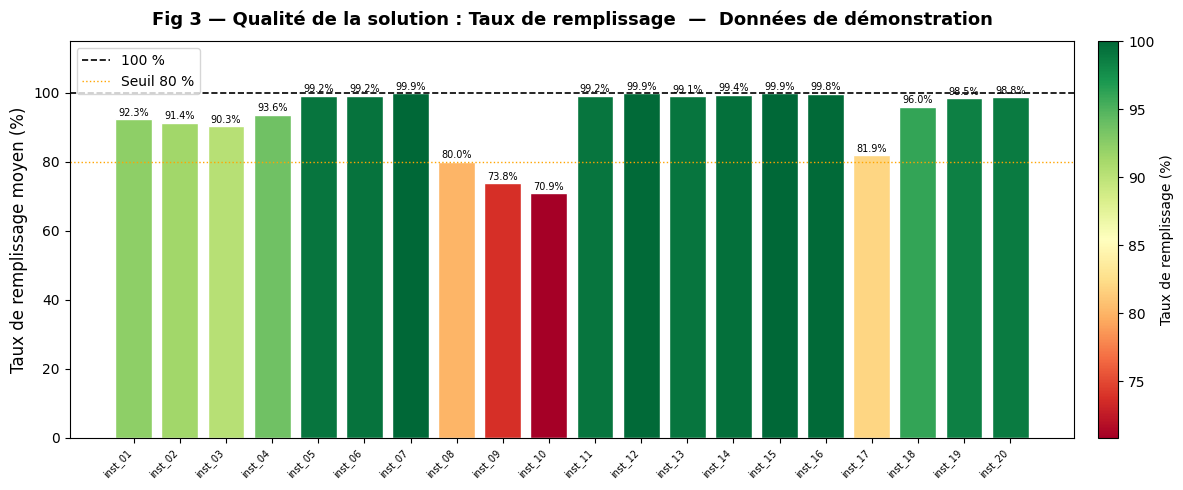

In [21]:
# ── Fig 3 : Taux de remplissage des bins ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(10, len(completed) * 0.65), 5))

fill_rates = [
    r.total_weight / (r.bins_used * r.bin_capacity) * 100
    for r in completed
]
cmap = matplotlib.colormaps["RdYlGn"]
norm = Normalize(min(fill_rates), 100)
bar_colors = [cmap(norm(v)) for v in fill_rates]

ax.bar(range(len(completed)), fill_rates, color=bar_colors, edgecolor="white")
ax.axhline(100, color="black",  linewidth=1.2, linestyle="--", label="100 %")
ax.axhline(80,  color="orange", linewidth=1.0, linestyle=":",  label="Seuil 80 %")

for i, rate in enumerate(fill_rates):
    ax.text(i, rate + 0.4, f"{rate:.1f}%", ha="center", va="bottom", fontsize=7)

sm = matplotlib.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label="Taux de remplissage (%)", pad=0.02)

ax.set_xticks(range(len(completed)))
ax.set_xticklabels([r.instance_name for r in completed], rotation=45, ha="right", fontsize=7)
ax.set_ylim(0, 115)
ax.set_ylabel("Taux de remplissage moyen (%)", fontsize=12)
ax.set_title(f"Fig 3 — Qualité de la solution : Taux de remplissage  —  {dataset_label}",
             fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=10)
fig.tight_layout()
plt.show()

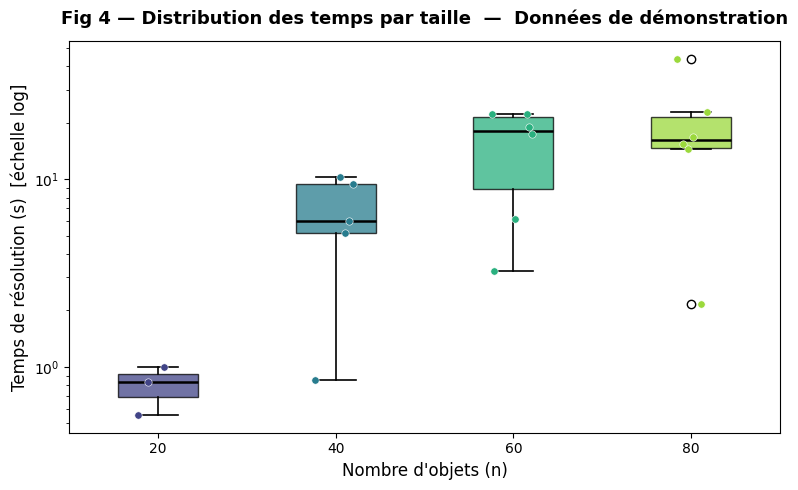

In [25]:
# ── Fig 4 : Distribution des temps par taille d'instance (Box plot) ───────────
size_groups: dict = {}
for r in completed:
    size_groups.setdefault(r.num_items, []).append(r.elapsed_time)

if len(size_groups) >= 2:
    fig, ax = plt.subplots(figsize=(8, 5))
    sorted_sizes  = sorted(size_groups.keys())
    group_times   = [size_groups[n] for n in sorted_sizes]
    labels        = [str(n) for n in sorted_sizes]

    box = ax.boxplot(
        group_times,
        tick_labels=labels,
        patch_artist=True,
        medianprops=dict(color="black", linewidth=1.8),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
    )
    viridis = matplotlib.colormaps["viridis"]
    palette = [viridis(v) for v in np.linspace(0.2, 0.85, len(sorted_sizes))]
    for patch, color in zip(box["boxes"], palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    rng = np.random.default_rng(seed=0)
    for idx, times in enumerate(group_times):
        jitter = rng.uniform(-0.12, 0.12, size=len(times))
        ax.scatter(np.full(len(times), idx + 1) + jitter, times,
                   s=28, zorder=3, edgecolors="white", linewidths=0.4, color=palette[idx])

    ax.set_yscale("log")
    ax.set_xlabel("Nombre d'objets (n)", fontsize=12)
    ax.set_ylabel("Temps de résolution (s)  [échelle log]", fontsize=12)
    ax.set_title(f"Fig 4 — Distribution des temps par taille  —  {dataset_label}",
                 fontsize=13, fontweight="bold", pad=12)
    fig.tight_layout()
    plt.show()
else:
    print("Toutes les instances ont la même taille.")

---

## 9. Statistiques récapitulatives

In [24]:
results_all = display_results
completed   = [r for r in results_all if not r.timed_out]
n_opt       = sum(1 for r in completed if r.bins_used == r.lower_bound)
timeout_n   = len(results_all) - len(completed)
avg_gap     = sum(r.bins_used - r.lower_bound for r in completed) / max(1, len(completed))
avg_fill    = sum(r.total_weight / (r.bins_used * r.bin_capacity) for r in completed) / max(1, len(completed)) * 100
total_time  = sum(r.elapsed_time for r in results_all)
avg_time    = sum(r.elapsed_time for r in completed) / max(1, len(completed))

print("═" * 48)
print(f"  STATISTIQUES RÉCAPITULATIVES — {dataset_label}")
print("═" * 48)
print(f"  Instances traitées      : {len(results_all)}")
print(f"  Gap moyen               : {avg_gap:.3f} bins")
print(f"  Taux de remplissage moy : {avg_fill:.1f} %")
print(f"  Temps total             : {total_time:.4f} s")
print(f"  Temps moyen (complètes) : {avg_time:.4f} s")
if timeout_n:
    print(f"  Timeouts                : {timeout_n}")
print("═" * 48)

════════════════════════════════════════════════
  STATISTIQUES RÉCAPITULATIVES — Données de démonstration
════════════════════════════════════════════════
  Instances traitées      : 20
  Gap moyen               : 0.750 bins
  Taux de remplissage moy : 93.2 %
  Temps total             : 240.4142 s
  Temps moyen (complètes) : 12.0207 s
════════════════════════════════════════════════


---

## 10. Conclusion

| Critère | Backtracking | Branch & Bound | DP (Bitmask) |
|---|---|---|---|
| **Optimalité** | Garantie | Garantie | Garantie |
| **Borne inférieure** | Non utilisée | L1 + pruning | Implicite |
| **Brisure de symétrie** | Oui | Oui | — |
| **Limite n** | ~30 (pratique) | ~60–80 | ≤ 20 |
| **Complexité** | $O(n! / k!)$ élaguée | Meilleure grâce au pruning | $O(3^n)$ |

**Points clés :**

- L'heuristique **FFD** fournit une borne supérieure de bonne qualité dès le départ, ce qui rend le pruning très efficace.
- La **brisure de symétrie** (ignorer les bins de même charge) est l'optimisation la plus impactante sur le backtracking pur.
- Le **Branch & Bound** avec la borne L1 est la méthode la plus robuste sur des instances de taille moyenne (jusqu'à ~80 objets avec un time limit).
- La **DP bitmask** est exacte et très rapide pour $n \leq 20$, mais sa complexité exponentielle en espace ($O(2^n)$) la rend inutilisable au-delà.